# Compare Global Views from Three TFRecord Files

This notebook loads three different TFRecord files and compares the global views from the first 10 examples in each dataset.


In [1]:
# %pip install --upgrade pip
# %pip install tensorflow
# import sys; print(sys.executable)  # sanity check: which Python the kernel is using
# import tensorflow as tf; print(tf.__version__)

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Define the three file paths
# files_april = '/Users/pablom.perez/Desktop/MIT-PhD-macbook/Astronet2025/data/00000-of-00005'
files_april = '/pdo/users/pablomer/mnt/tess/astronet/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-test/00000-of-00005'
# files_oct25 = '/Users/pablom.perez/Desktop/MIT-PhD-macbook/Astronet2025/data/00000-of-00050'
# files_oct25 = '/pdo/astronet-data/data/tfrecords/oct2025_original/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-train/00000-of-00050'
files_oct25= '/pdo/astronet-data/data/tfrecords/oct2025_30minbin/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-test/00000-of-00050'
# files_oct25_cadencebin = '/Users/pablom.perez/Desktop/MIT-PhD-macbook/Astronet2025/data/00000-of-00050-cadencebin'
files_oct25_cadencebin = '/pdo/astronet-data/data/tfrecords/oct2025_cadencebin/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-test/00000-of-00050'

# List of file paths and their labels
file_paths = [files_april, files_oct25_cadencebin, files_oct25]
file_labels = ['April', 'Oct25_CadenceBin', 'Oct25_30min']

print("File paths defined:")
for i, (path, label) in enumerate(zip(file_paths, file_labels)):
    print(f"{i+1}. {label}: {path}")


2025-10-28 17:58:35.110338: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-28 17:58:54.200876: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


File paths defined:
1. April: /pdo/users/pablomer/mnt/tess/astronet/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-test/00000-of-00005
2. Oct25_30min: /pdo/astronet-data/data/tfrecords/oct2025_30minbin/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-test/00000-of-00050
3. Oct25_CadenceBin: /pdo/astronet-data/data/tfrecords/oct2025_cadencebin/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-test/00000-of-00050


In [3]:
def load_tfrecord_examples(file_path, num_examples=20):
    """
    Load the first num_examples from a TFRecord file and extract global_view data.

    Args:
        file_path (str): Path to the TFRecord file
        num_examples (int): Number of examples to load

    Returns:
        list: List of global_view arrays for each example
    """
    global_views = []
    astro_ids = []

    try:
        raw_dataset = tf.data.TFRecordDataset([file_path])

        for i, raw_record in enumerate(raw_dataset.take(num_examples)):
            example = tf.train.Example()
            example.ParseFromString(raw_record.numpy())

            # Extract global_view
            if 'global_view' in example.features.feature:
                global_view = list(example.features.feature['global_view'].float_list.value)
                global_views.append(np.array(global_view))
            else:
                print(f"Warning: global_view not found in example {i}")
                global_views.append(None)

            # Extract astro_id for reference - following original code pattern
            if 'astro_id' in example.features.feature:
                astro_id_bytes = example.features.feature['astro_id'].bytes_list.value
                if len(astro_id_bytes) > 0:
                    # Decode all bytes and join them (following original code pattern)
                    astro_id = ''.join([v.decode("utf-8") for v in astro_id_bytes])
                    astro_ids.append(astro_id)
                else:
                    astro_ids.append(f"example_{i}")
            else:
                astro_ids.append(f"example_{i}")

    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return [], []

    return global_views, astro_ids

print("Function defined to load TFRecord examples")


Function defined to load TFRecord examples


In [4]:
# Load data from all three files
all_global_views = []
all_astro_ids = []

print("Loading data from all three TFRecord files...")
for i, (file_path, label) in enumerate(zip(file_paths, file_labels)):
    print(f"\nLoading {label} ({file_path})...")
    global_views, astro_ids = load_tfrecord_examples(file_path, num_examples=20)
    all_global_views.append(global_views)
    all_astro_ids.append(astro_ids)
    print(f"Loaded {len(global_views)} examples from {label}")

print(f"\nData loading complete!")
print(f"Total datasets: {len(all_global_views)}")
for i, (views, ids) in enumerate(zip(all_global_views, all_astro_ids)):
    print(f"Dataset {i+1} ({file_labels[i]}): {len(views)} examples")


Loading data from all three TFRecord files...

Loading April (/pdo/users/pablomer/mnt/tess/astronet/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-test/00000-of-00005)...


2025-10-28 17:59:39.186397: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 78931 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:85:00.0, compute capability: 8.0
2025-10-28 17:59:39.188003: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 78931 MB memory:  -> device: 1, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:86:00.0, compute capability: 8.0
2025-10-28 17:59:39.189572: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 22128 MB memory:  -> device: 2, name: NVIDIA A30, pci bus id: 0000:05:00.0, compute capability: 8.0
2025-10-28 17:59:39.191021: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 22128 MB memory:  -> device: 3, name: NVIDIA A30, pci bus id: 0000:06:00.0, co

Loaded 20 examples from April

Loading Oct25_30min (/pdo/astronet-data/data/tfrecords/oct2025_30minbin/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-test/00000-of-00050)...
Loaded 20 examples from Oct25_30min

Loading Oct25_CadenceBin (/pdo/astronet-data/data/tfrecords/oct2025_cadencebin/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-test/00000-of-00050)...


2025-10-28 17:59:40.612279: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1]
	 [[{{node Placeholder/_0}}]]
2025-10-28 17:59:40.751714: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1]
	 [[{{node Placeholder/_0}}]]


Loaded 20 examples from Oct25_CadenceBin

Data loading complete!
Total datasets: 3
Dataset 1 (April): 20 examples
Dataset 2 (Oct25_30min): 20 examples
Dataset 3 (Oct25_CadenceBin): 20 examples


In [5]:
def plot_global_view_comparison(example_idx):
    """
    Plot global views from all three datasets for a specific example.

    Args:
        example_idx (int): Index of the example to plot (0-9)
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for i, (views, label) in enumerate(zip(all_global_views, file_labels)):
        if example_idx < len(views) and views[example_idx] is not None:
            axes[i].plot(views[example_idx], linewidth=1)
            axes[i].set_title(f'{label}\nAstro ID: {all_astro_ids[i][example_idx]}')
            axes[i].set_xlabel('Time Index')
            axes[i].set_ylabel('Flux')
            axes[i].grid(True, alpha=0.3)
            axes[i].set_ylim(-1.05, 0.3)
        else:
            axes[i].text(0.5, 0.5, f'No data available\nfor example {example_idx}',
                        ha='center', va='center', transform=axes[i].transAxes)
            axes[i].set_title(f'{label} - No Data')

    plt.suptitle(f'Global View Comparison - Example {example_idx + 1}', fontsize=14)
    plt.tight_layout()
    plt.show()

print("Function defined to plot global view comparisons")


Function defined to plot global view comparisons


Generating comparison plots for all examples...

Plotting example 1...


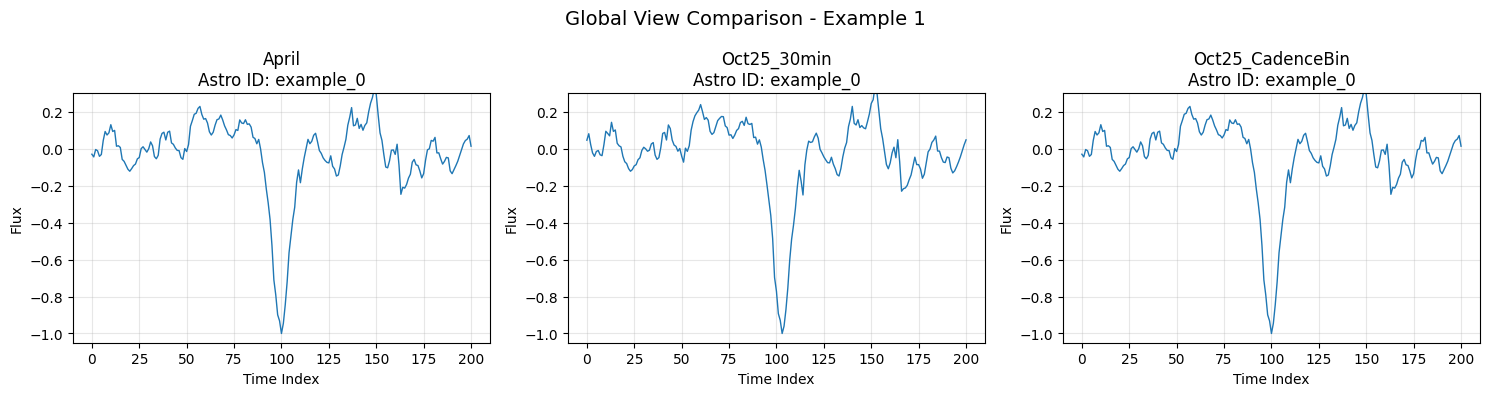


Plotting example 2...


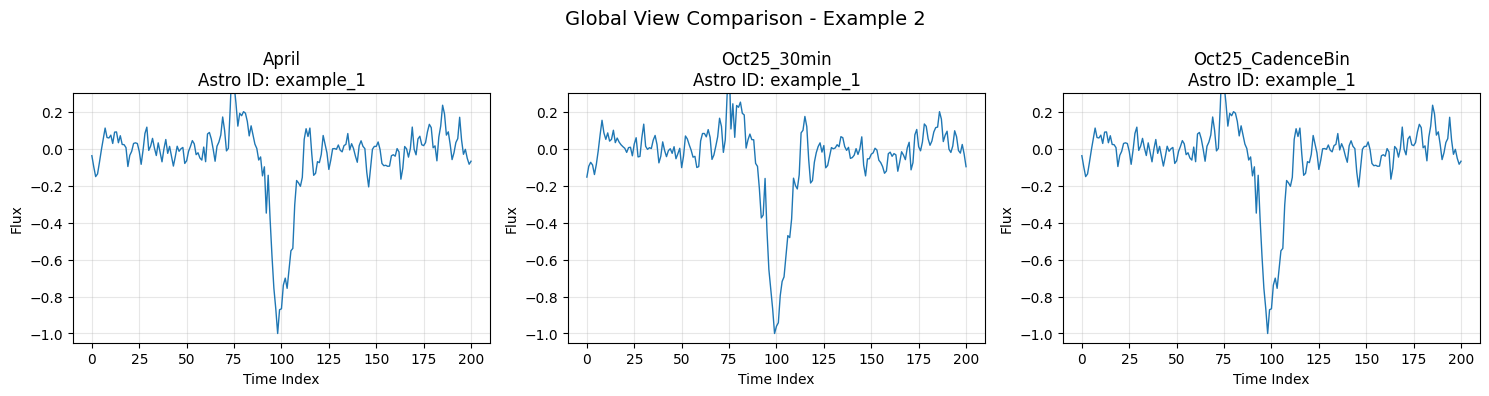


Plotting example 3...


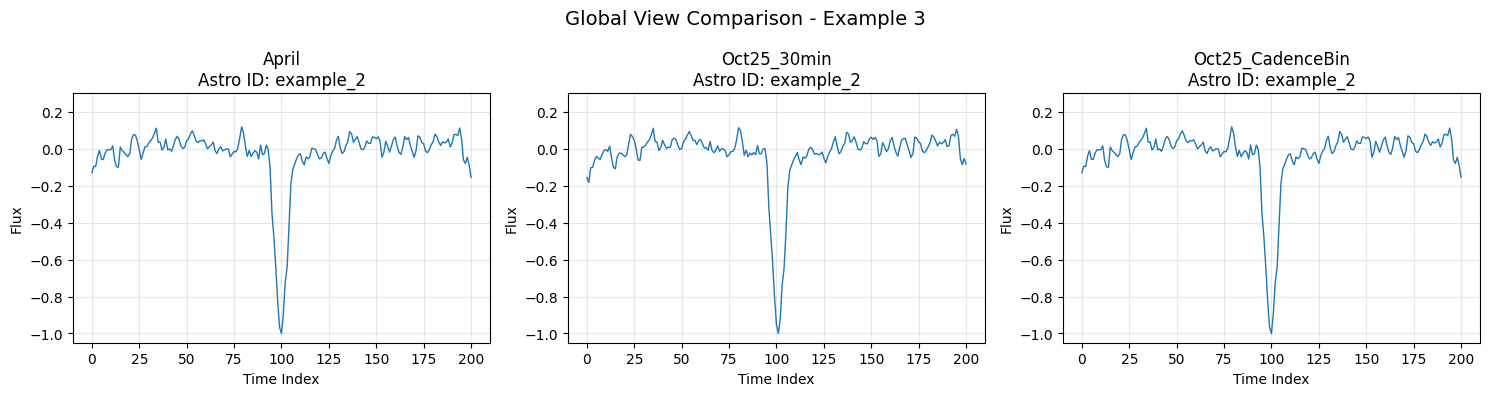


Plotting example 4...


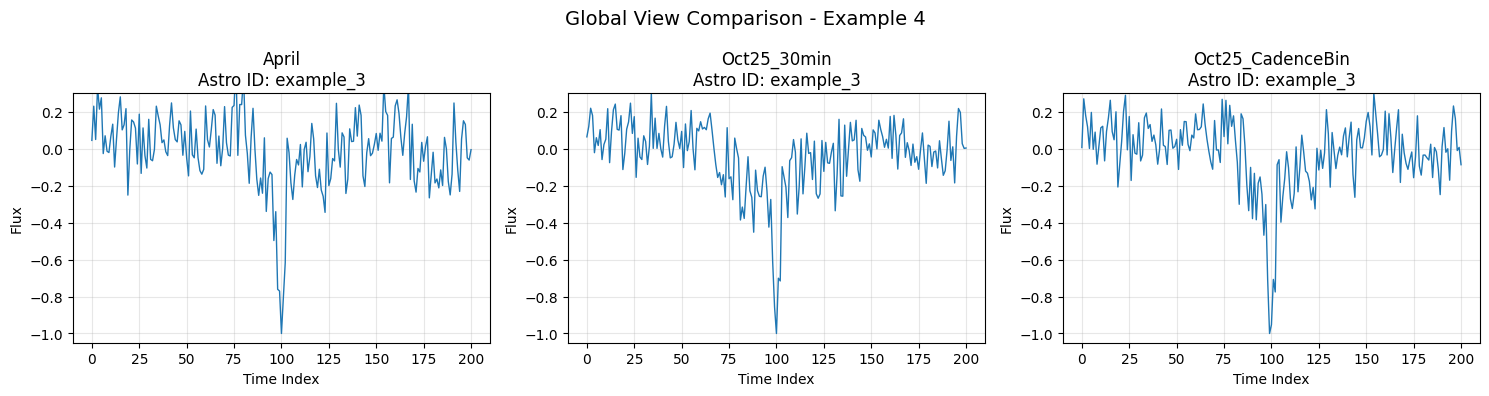


Plotting example 5...


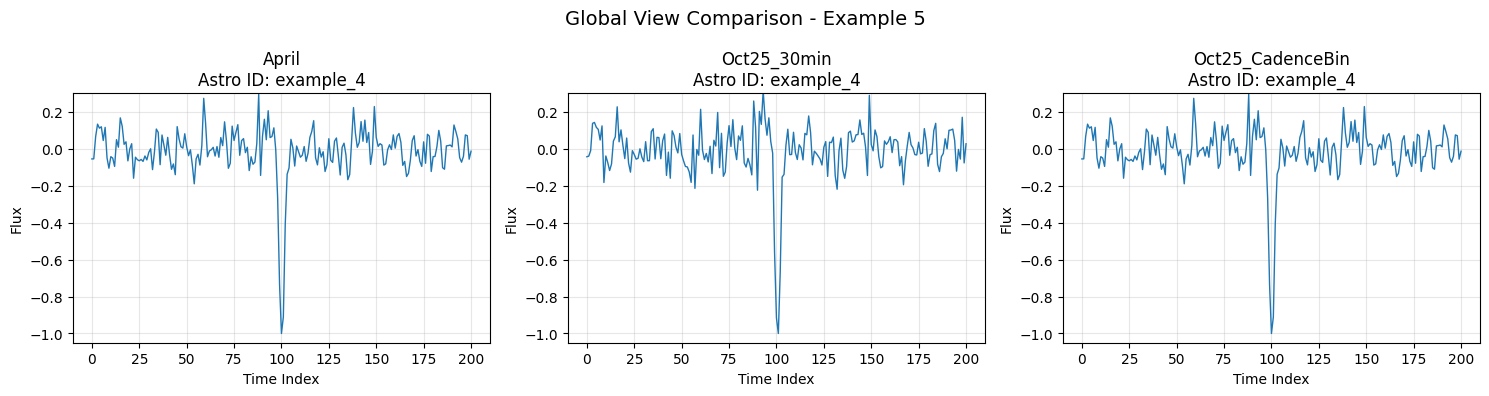


Plotting example 6...


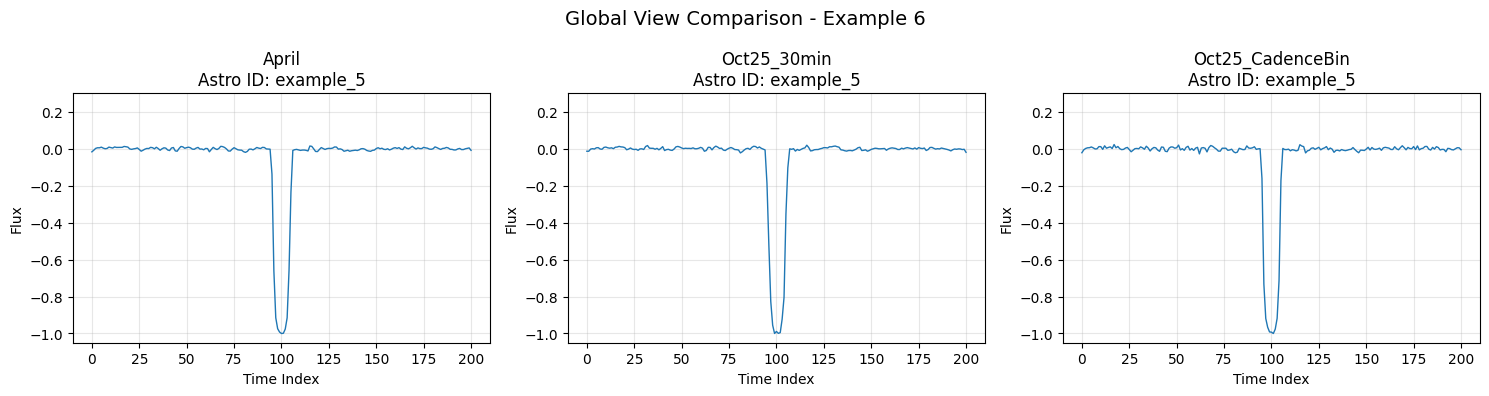


Plotting example 7...


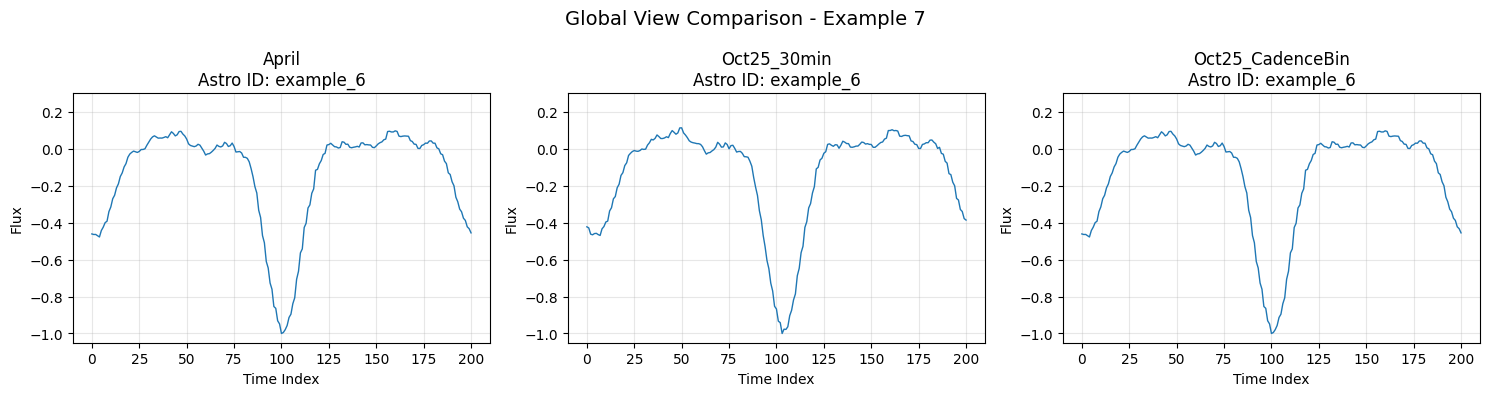


Plotting example 8...


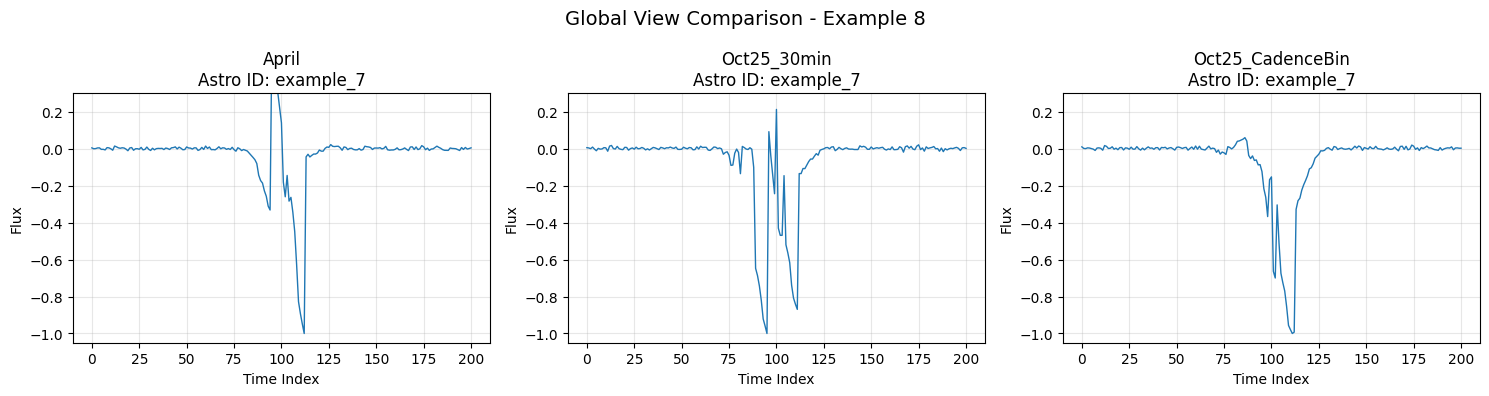


Plotting example 9...


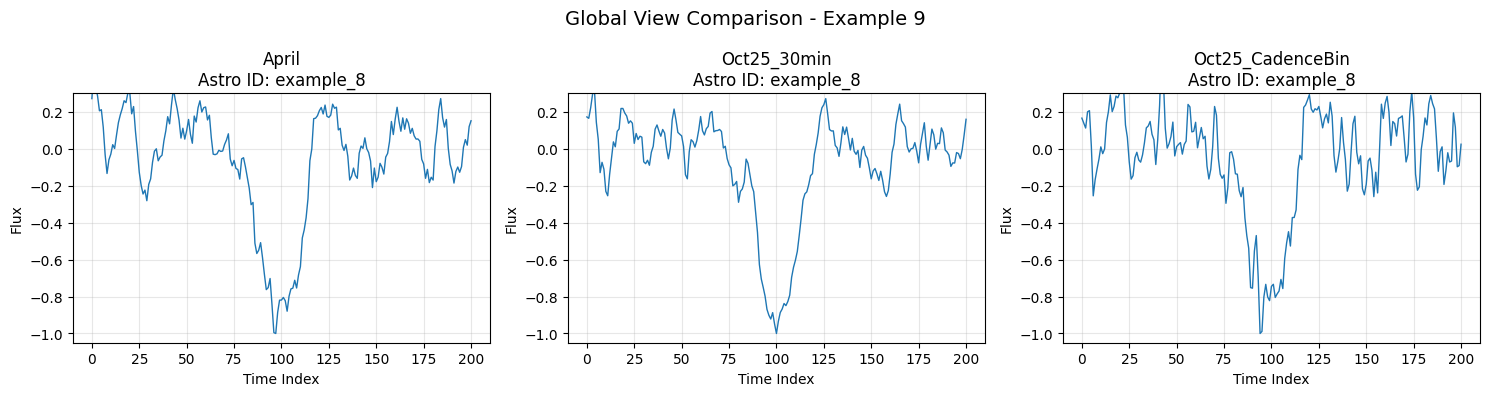


Plotting example 10...


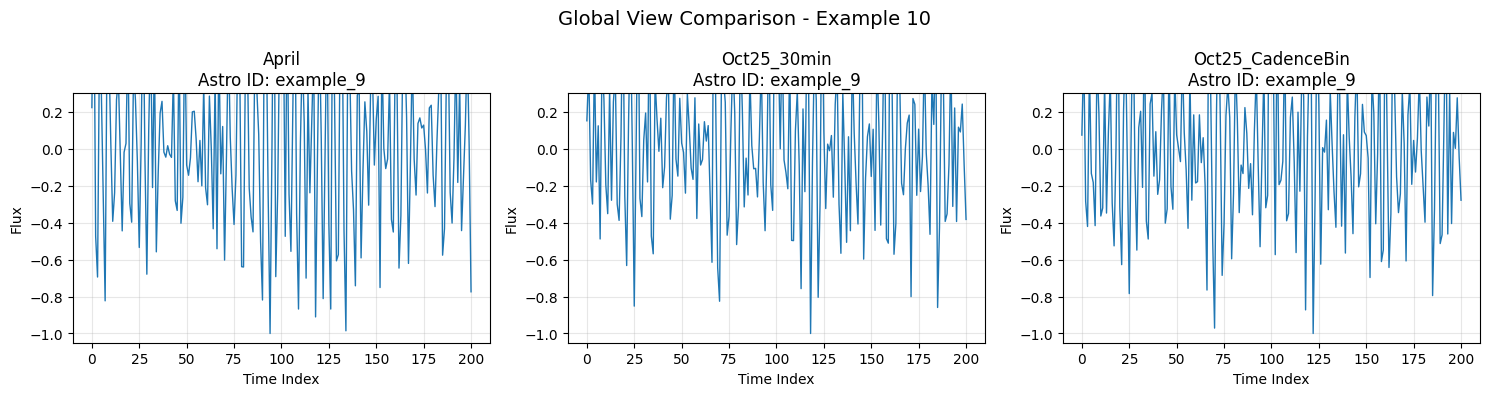


Plotting example 11...


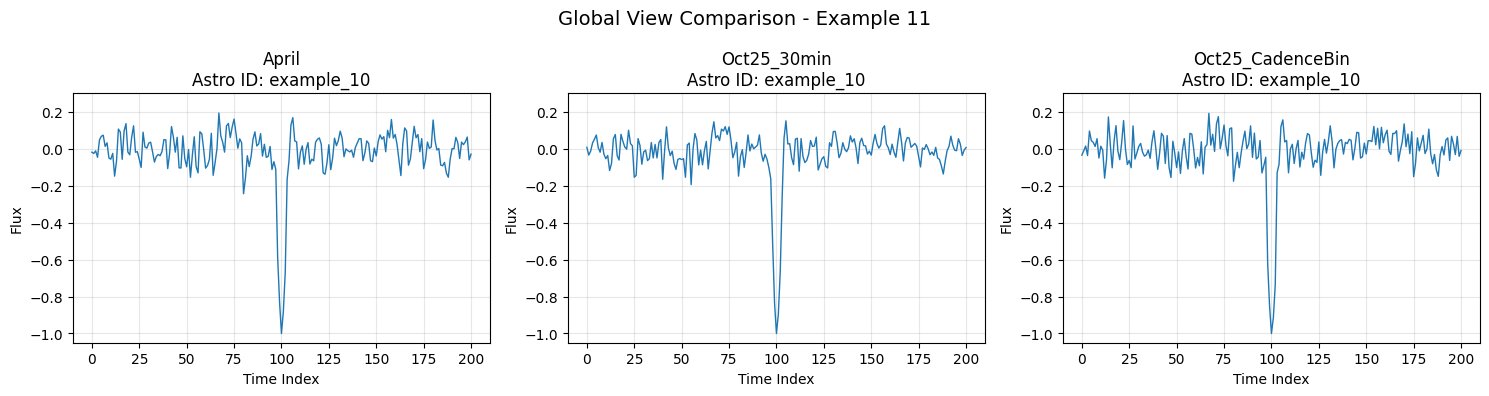


Plotting example 12...


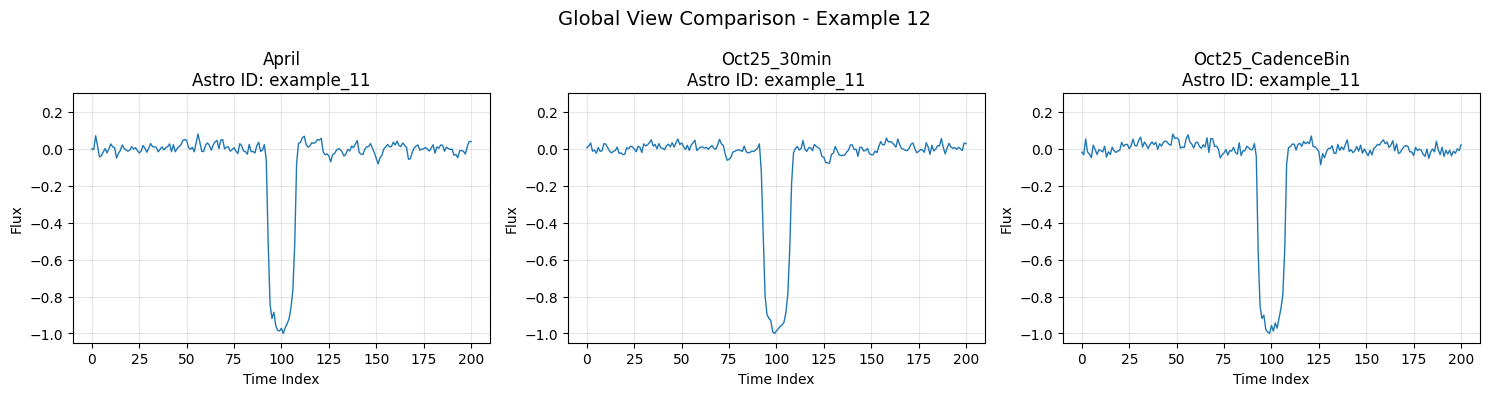


Plotting example 13...


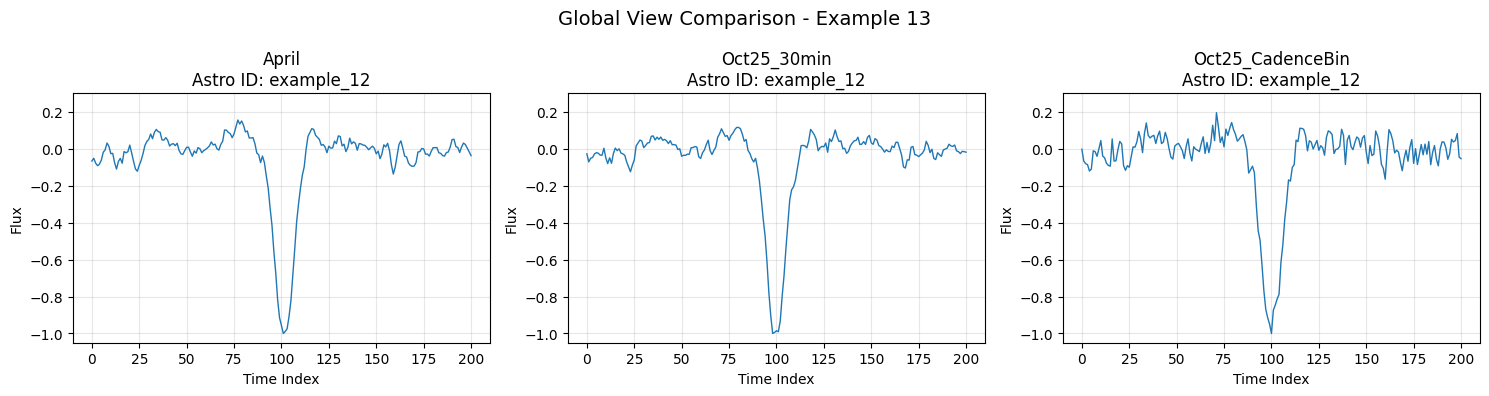


Plotting example 14...


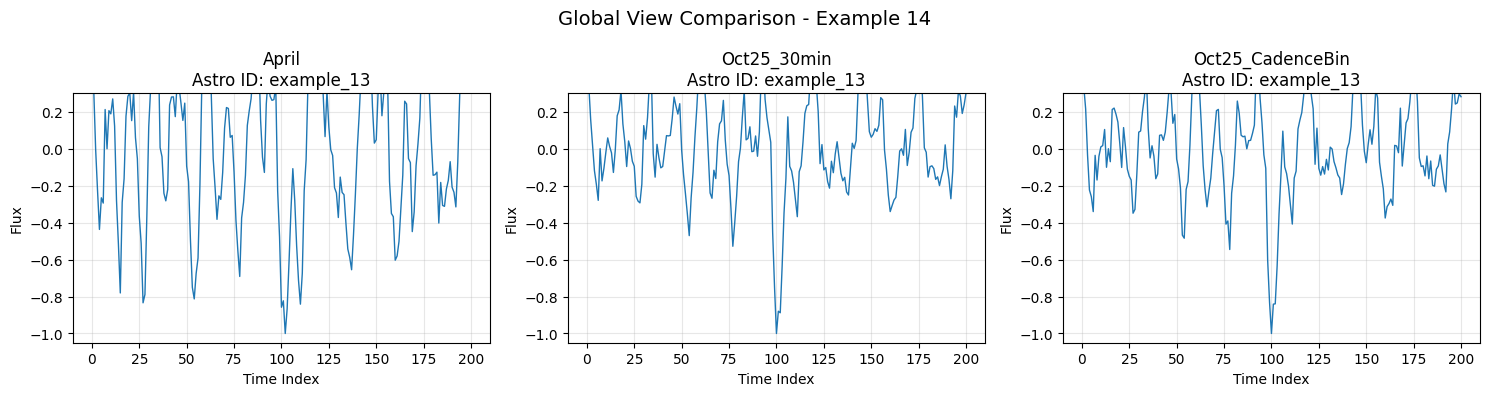


Plotting example 15...


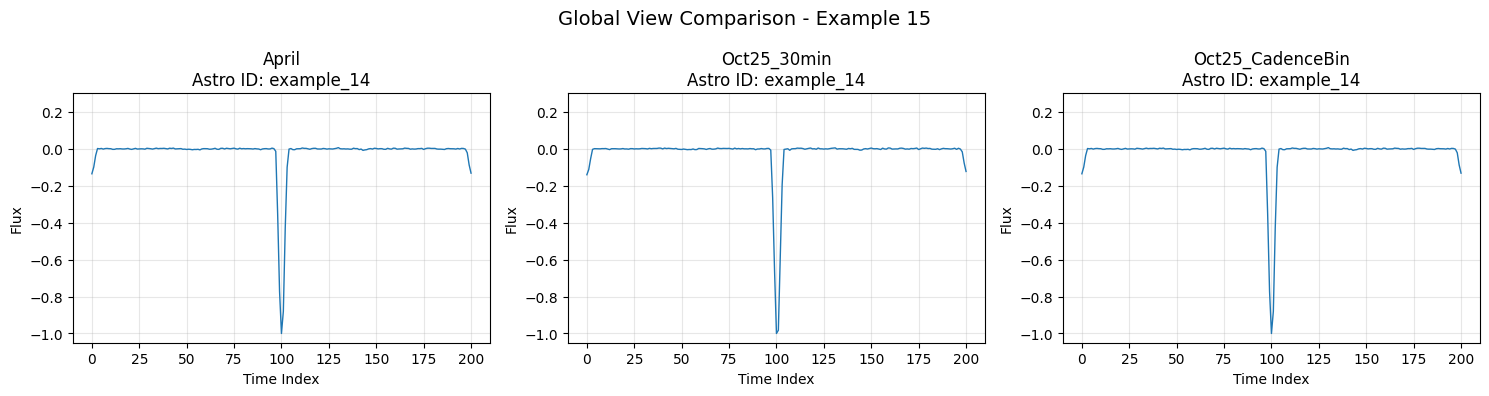


Plotting example 16...


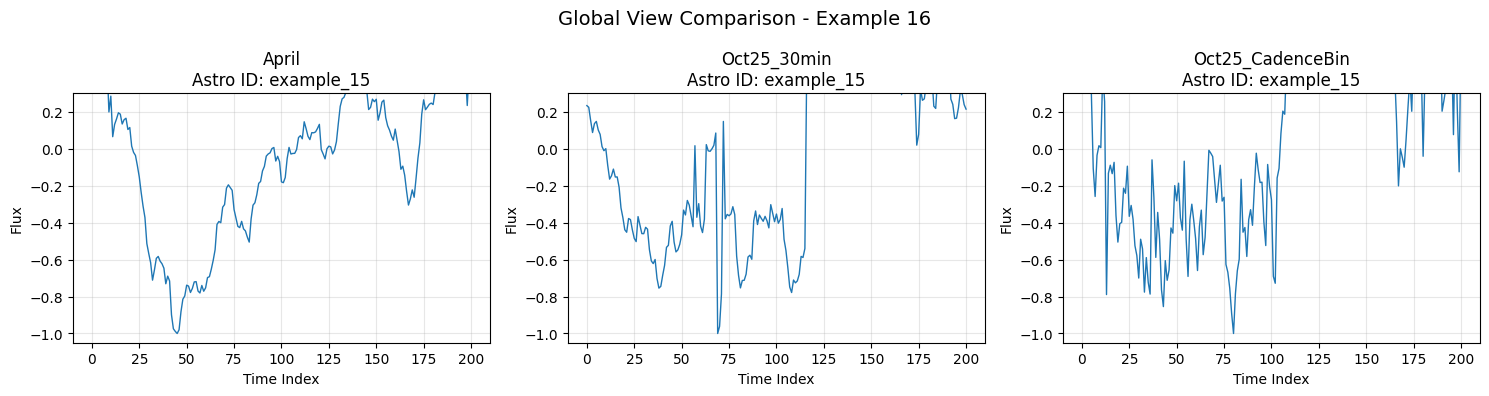


Plotting example 17...


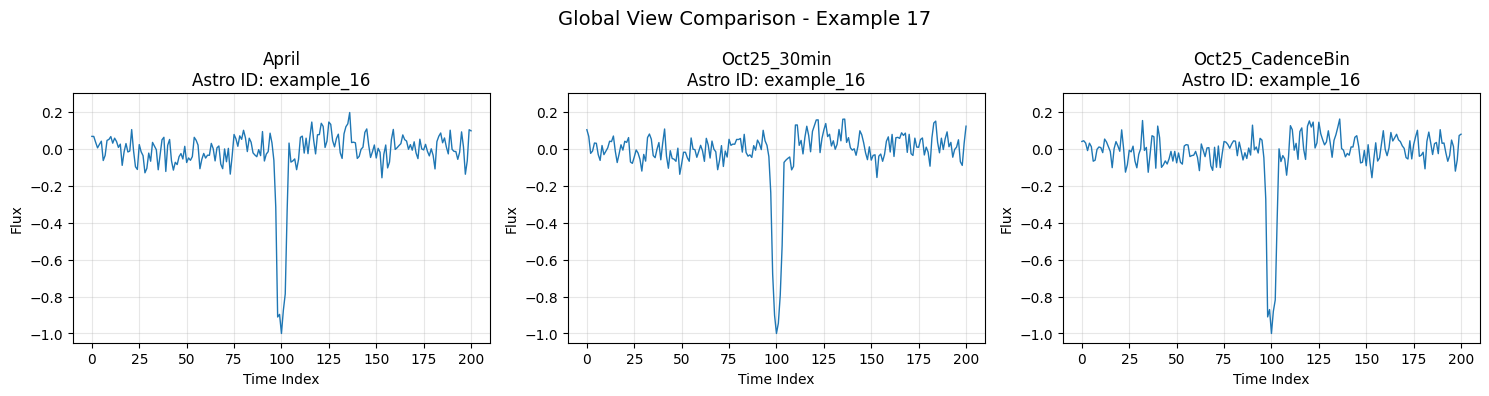


Plotting example 18...


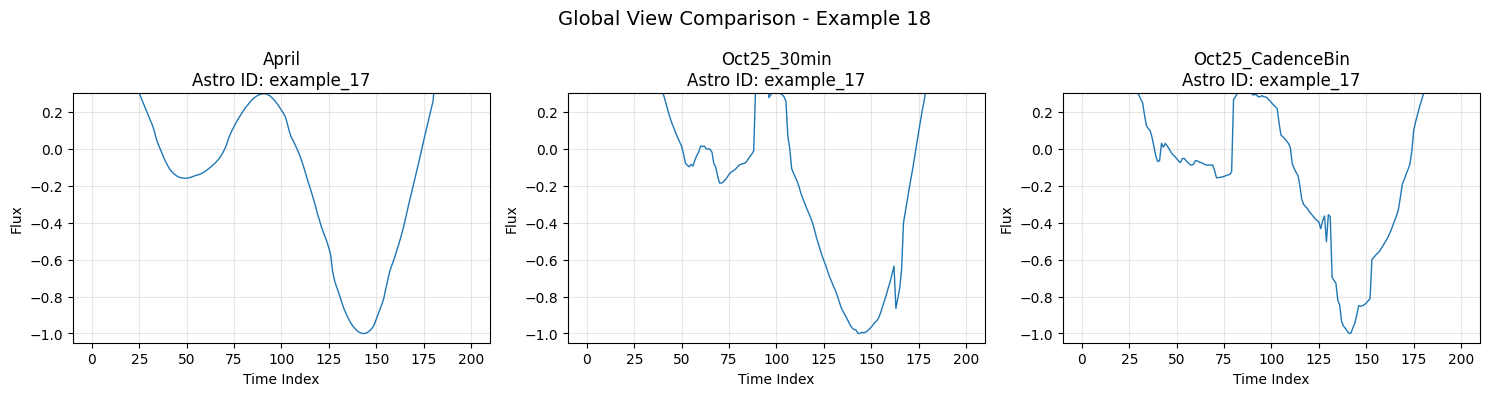


Plotting example 19...


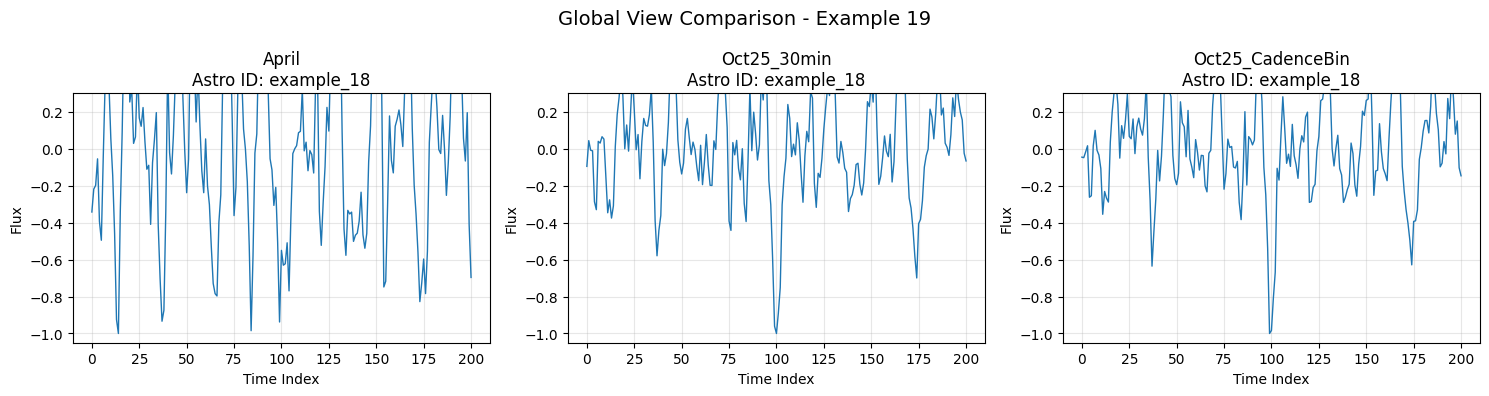


Plotting example 20...


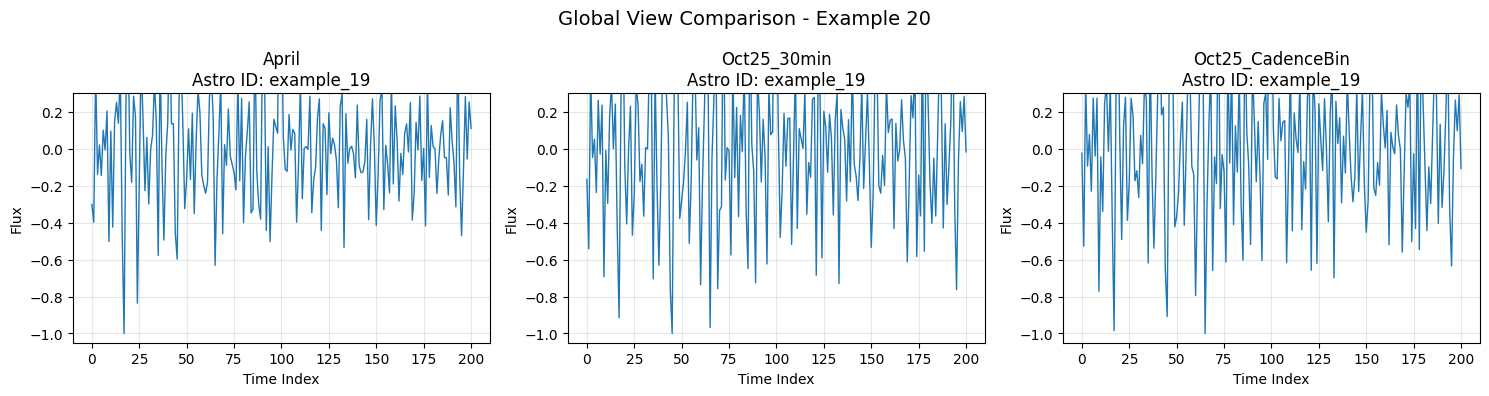

In [6]:
# Generate comparison plots for all 10 examples
print("Generating comparison plots for all examples...")

for example_idx in range(20):
    print(f"\nPlotting example {example_idx + 1}...")
    plot_global_view_comparison(example_idx)


In [8]:
def plot_global_view_differences(example_idx):
    """
    Plot differences between global views from different datasets for a specific example.

    Args:
        example_idx (int): Index of the example to plot (0-9)
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Check if we have data for this example
    if (example_idx < len(all_global_views[0]) and all_global_views[0][example_idx] is not None and
        example_idx < len(all_global_views[1]) and all_global_views[1][example_idx] is not None and
        example_idx < len(all_global_views[2]) and all_global_views[2][example_idx] is not None):

        april_view = all_global_views[0][example_idx]
        oct25_view = all_global_views[1][example_idx]
        oct25_cadencebin_view = all_global_views[2][example_idx]

        # Difference 1: April - Oct25
        diff1 = april_view - oct25_cadencebin_view
        axes[0].plot(diff1, linewidth=1, color='blue')
        axes[0].set_title(f'April - Oct25_CadenceBin\nAstro ID: {all_astro_ids[0][example_idx]}')
        axes[0].set_xlabel('Time Index')
        axes[0].set_ylabel('Flux Difference')
        axes[0].grid(True, alpha=0.3)
        axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)

        # Difference 2: Oct25 - Oct25_CadenceBin
        diff2 = april_view - oct25_view
        axes[1].plot(diff2, linewidth=1, color='green')
        axes[1].set_title(f'April - Oct25_30minBin\nAstro ID: {all_astro_ids[1][example_idx]}')
        axes[1].set_xlabel('Time Index')
        axes[1].set_ylabel('Flux Difference')
        axes[1].grid(True, alpha=0.3)
        axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)

        # Set consistent y-axis limits based on the range of differences
        all_diffs = np.concatenate([diff1, diff2])
        y_min, y_max = np.min(all_diffs), np.max(all_diffs)
        y_range = y_max - y_min
        y_margin = y_range * 0.1
        axes[0].set_ylim(y_min - y_margin, y_max + y_margin)
        axes[1].set_ylim(y_min - y_margin, y_max + y_margin)

    else:
        # Handle case where data is not available
        for i, label in enumerate(['April - Oct25', 'Oct25 - Oct25_CadenceBin']):
            axes[i].text(0.5, 0.5, f'No data available\nfor example {example_idx}',
                        ha='center', va='center', transform=axes[i].transAxes)
            axes[i].set_title(f'{label} - No Data')

    plt.suptitle(f'Global View Differences - Example {example_idx + 1}', fontsize=14)
    plt.tight_layout()
    plt.show()

print("Function defined to plot global view differences")


Function defined to plot global view differences


Generating difference plots for all examples...

Plotting differences for example 1...


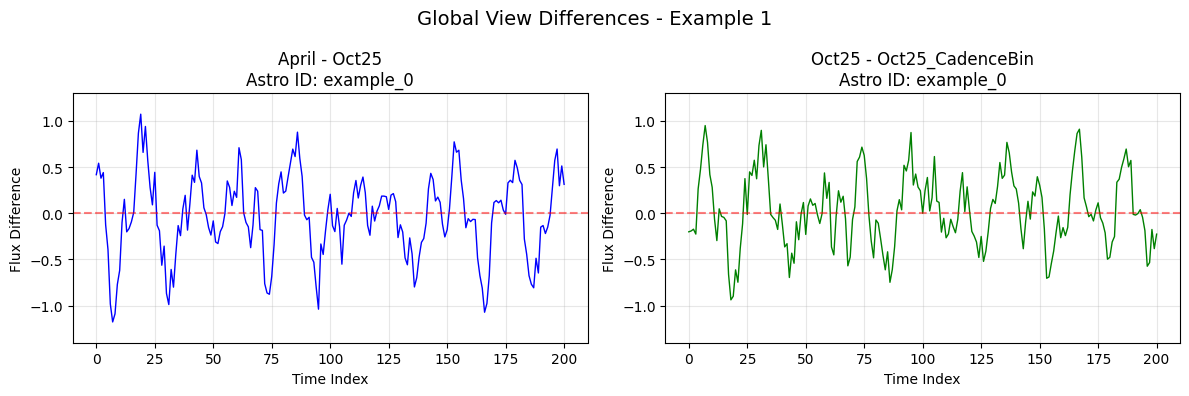


Plotting differences for example 2...


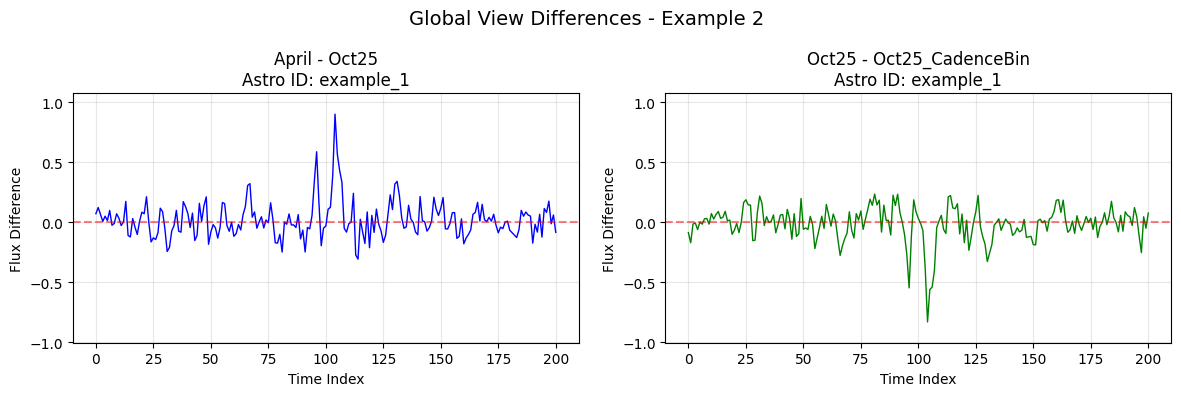


Plotting differences for example 3...


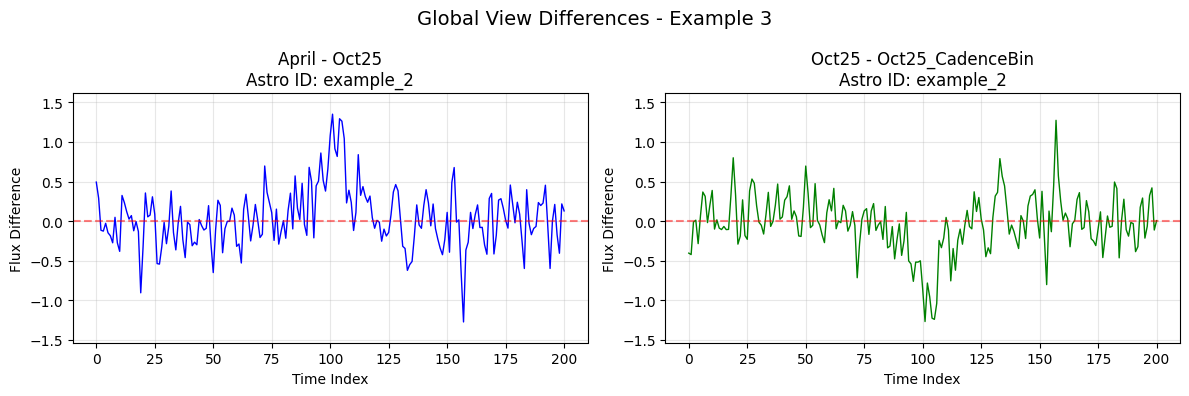


Plotting differences for example 4...


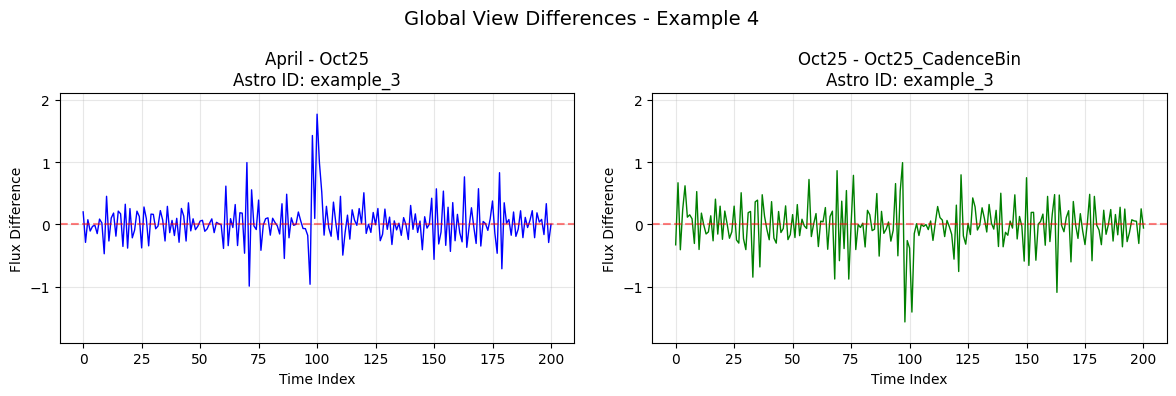


Plotting differences for example 5...


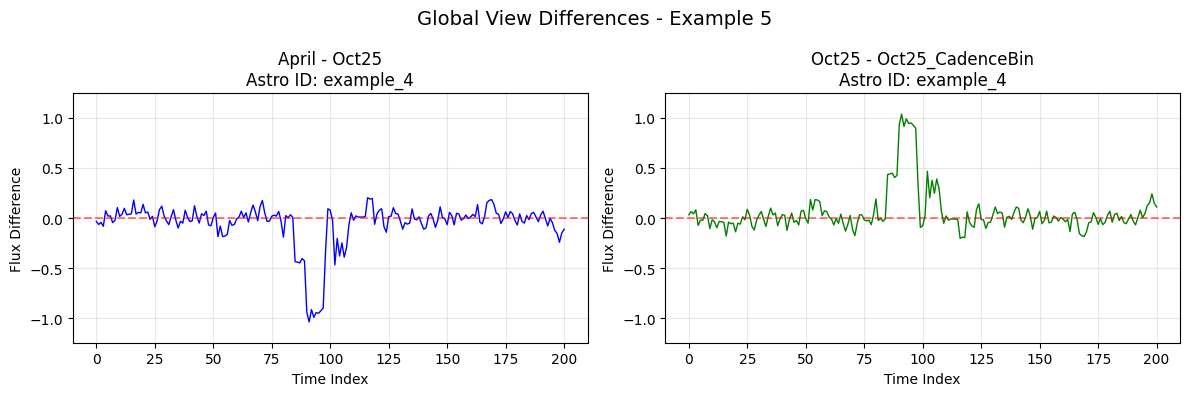


Plotting differences for example 6...


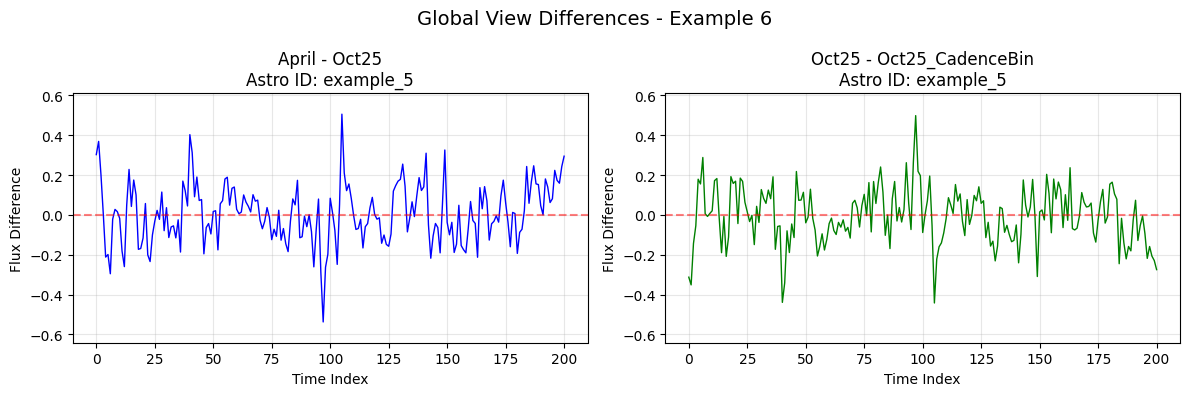


Plotting differences for example 7...


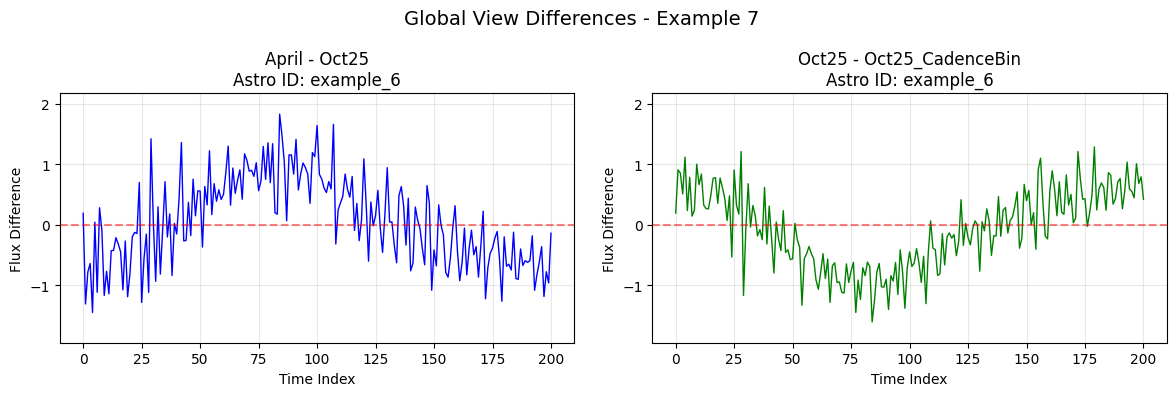


Plotting differences for example 8...


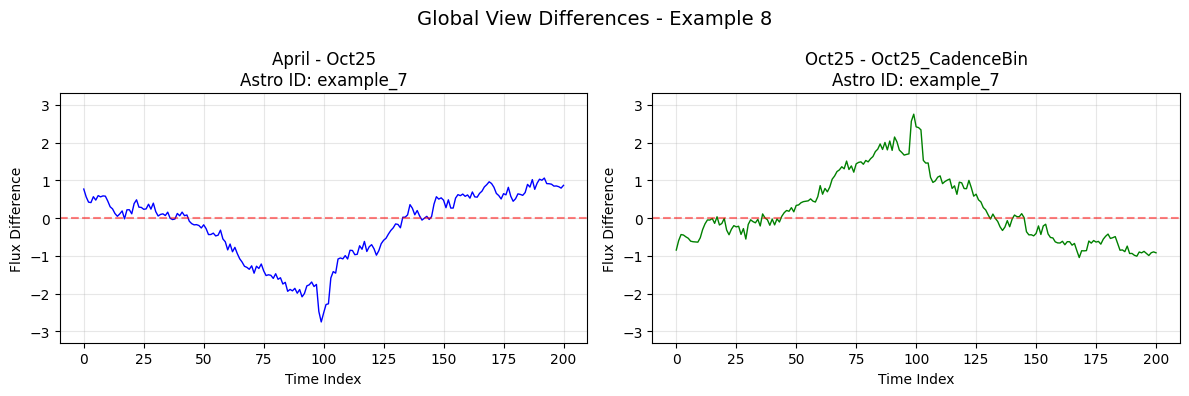


Plotting differences for example 9...


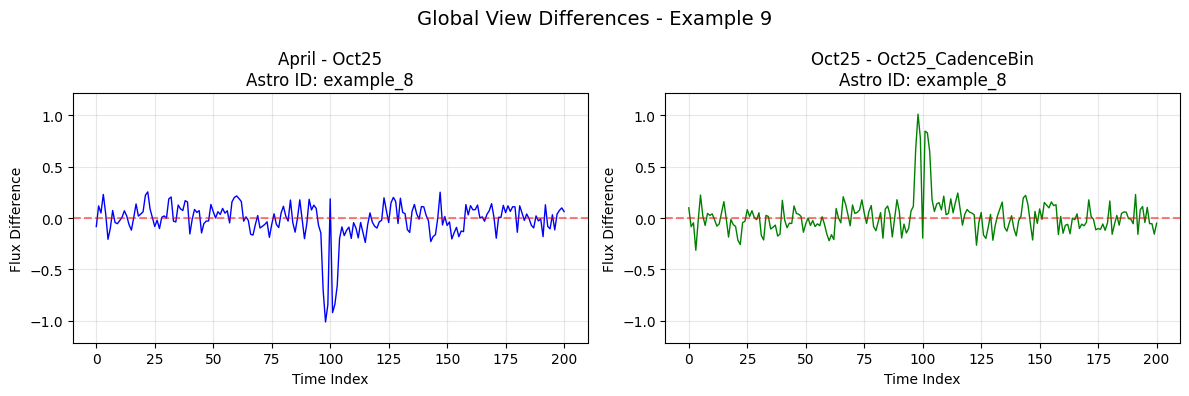


Plotting differences for example 10...


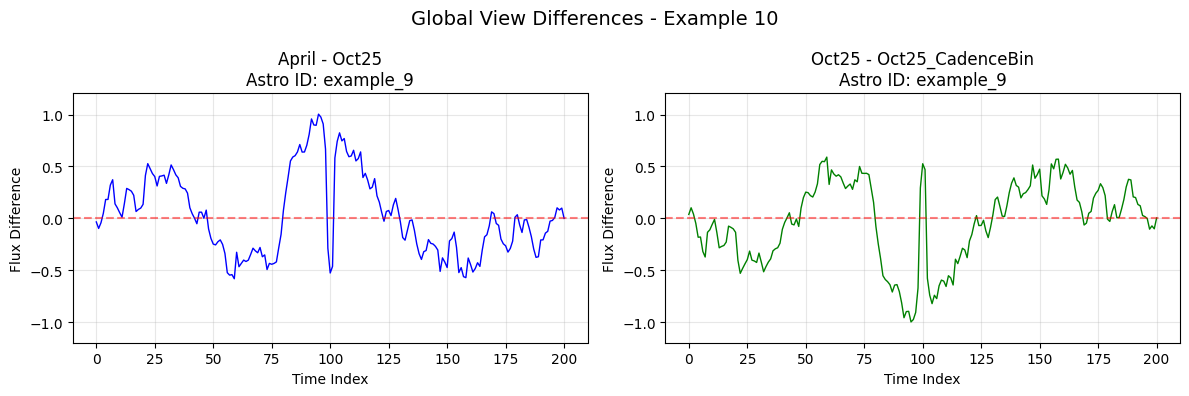

In [35]:
# Generate difference plots for all 10 examples
print("Generating difference plots for all examples...")

for example_idx in range(10):
    print(f"\nPlotting differences for example {example_idx + 1}...")
    plot_global_view_differences(example_idx)


## Summary

This notebook has loaded the first 10 examples from each of the three TFRecord files and generated two types of comparison plots:

### 1. Global View Comparisons
Each plot shows the global views side by side from all three datasets:
- **April dataset**: Global view from the April TFRecord file
- **Oct25 dataset**: Global view from the October 25 TFRecord file  
- **Oct25_CadenceBin dataset**: Global view from the October 25 CadenceBin TFRecord file

### 2. Difference Plots
Each difference plot shows the flux differences between datasets:
- **Left plot**: April - Oct25 (shows how April differs from Oct25)
- **Right plot**: Oct25 - Oct25_CadenceBin (shows how Oct25 differs from Oct25_CadenceBin)

The difference plots include:
- A red dashed line at y=0 for reference
- Consistent y-axis scaling to compare the magnitude of differences
- Grid lines for easier reading

These plots allow you to visually compare how the global views differ between the different datasets and quantify the differences between them.


In [36]:
def check_disposition_fields(file_path, label, num_examples=5):
    """
    Check if disp_e and disp_p fields are present in a TFRecord file.

    Args:
        file_path (str): Path to the TFRecord file
        label (str): Label for the dataset
        num_examples (int): Number of examples to check
    """
    print(f"\nChecking disposition fields in {label}...")
    print(f"File: {file_path}")

    try:
        raw_dataset = tf.data.TFRecordDataset([file_path])

        disp_e_values = []
        disp_p_values = []
        astro_ids = []

        for i, raw_record in enumerate(raw_dataset.take(num_examples)):
            example = tf.train.Example()
            example.ParseFromString(raw_record.numpy())

            # Extract astro_id
            if 'astro_id' in example.features.feature:
                astro_id_bytes = example.features.feature['astro_id'].bytes_list.value
                if len(astro_id_bytes) > 0:
                    astro_id = ''.join([v.decode("utf-8") for v in astro_id_bytes])
                    astro_ids.append(astro_id)
                else:
                    astro_ids.append(f"example_{i}")
            else:
                astro_ids.append(f"example_{i}")

            # Check for disp_e
            if 'disp_e' in example.features.feature:
                disp_e = example.features.feature['disp_e'].int64_list.value
                if len(disp_e) > 0:
                    disp_e_values.append(disp_e[0])
                else:
                    disp_e_values.append(None)
            else:
                disp_e_values.append("NOT_FOUND")

            # Check for disp_p
            if 'disp_p' in example.features.feature:
                disp_p = example.features.feature['disp_p'].int64_list.value
                if len(disp_p) > 0:
                    disp_p_values.append(disp_p[0])
                else:
                    disp_p_values.append(None)
            else:
                disp_p_values.append("NOT_FOUND")

        # Print results
        print(f"Results for {label}:")
        print(f"  disp_e present: {'disp_e' in example.features.feature}")
        print(f"  disp_p present: {'disp_p' in example.features.feature}")

        if disp_e_values or disp_p_values:
            print(f"  Sample values (first {num_examples} examples):")
            for i in range(min(num_examples, len(astro_ids))):
                print(f"    Astro ID: {astro_ids[i]}")
                print(f"      disp_e: {disp_e_values[i]}")
                print(f"      disp_p: {disp_p_values[i]}")

        return disp_e_values, disp_p_values, astro_ids

    except Exception as e:
        print(f"Error checking {file_path}: {e}")
        return [], [], []

print("Function defined to check disposition fields")


Function defined to check disposition fields


In [37]:
# Check disposition fields in all three datasets
print("="*60)
print("CHECKING DISPOSITION FIELDS (disp_e and disp_p)")
print("="*60)

disposition_results = {}

for i, (file_path, label) in enumerate(zip(file_paths, file_labels)):
    disp_e_vals, disp_p_vals, astro_ids = check_disposition_fields(file_path, label, num_examples=5)
    disposition_results[label] = {
        'disp_e_values': disp_e_vals,
        'disp_p_values': disp_p_vals,
        'astro_ids': astro_ids
    }

print("\n" + "="*60)
print("SUMMARY OF DISPOSITION FIELDS")
print("="*60)

for label, results in disposition_results.items():
    print(f"\n{label}:")
    disp_e_present = any(val != "NOT_FOUND" for val in results['disp_e_values'])
    disp_p_present = any(val != "NOT_FOUND" for val in results['disp_p_values'])
    print(f"  disp_e: {'✓ Present' if disp_e_present else '✗ Not found'}")
    print(f"  disp_p: {'✓ Present' if disp_p_present else '✗ Not found'}")

    if disp_e_present:
        unique_disp_e = set(val for val in results['disp_e_values'] if val != "NOT_FOUND")
        print(f"  disp_e values: {sorted(unique_disp_e)}")

    if disp_p_present:
        unique_disp_p = set(val for val in results['disp_p_values'] if val != "NOT_FOUND")
        print(f"  disp_p values: {sorted(unique_disp_p)}")


CHECKING DISPOSITION FIELDS (disp_e and disp_p)

Checking disposition fields in April...
File: /pdo/users/pablomer/mnt/tess/astronet/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-val/00000-of-00005
Results for April:
  disp_e present: True
  disp_p present: True
  Sample values (first 5 examples):
    Astro ID: example_0
      disp_e: 0
      disp_p: 0
    Astro ID: example_1
      disp_e: 0
      disp_p: 1
    Astro ID: example_2
      disp_e: 0
      disp_p: 0
    Astro ID: example_3
      disp_e: 0
      disp_p: 0
    Astro ID: example_4
      disp_e: 1
      disp_p: 0

Checking disposition fields in Oct25_30min...
File: /pdo/astronet-data/data/tfrecords/oct2025_30minbin/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-train/00000-of-00050
Results for Oct25_30min:
  disp_e present: True
  disp_p present: True
  Sample values (first 5 examples):
    Astro ID: example_0
      disp_e: 0
      disp_p: 0
    Astro ID: example_1
      disp_e: 1
      disp_p: 0
    Astro

2025-10-27 18:10:13.833693: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1]
	 [[{{node Placeholder/_0}}]]
2025-10-27 18:10:13.862644: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1]
	 [[{{node Placeholder/_0}}]]
2025-10-27 18:10:13.890734: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1]
	 [[{{n

## Summary

This notebook has loaded the first 10 examples from each of the three TFRecord files and generated comparison plots showing the global views side by side. Each plot shows:

1. **April dataset**: Global view from the April TFRecord file
2. **Oct25 dataset**: Global view from the October 25 TFRecord file  
3. **Oct25_CadenceBin dataset**: Global view from the October 25 CadenceBin TFRecord file

The plots allow you to visually compare how the global views differ between the different datasets for the same examples.
